# ** Business Problem**

Understanding user behavior is essential for improving conversion rates in e-commerce platforms.

This project aims to analyze user activity data to identify patterns in the purchasing process and determine where users drop off in the purchase funnel.

# **Prepare data**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
## Data Loading
df = pd.read_csv("2019-Oct.csv")
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2.103810e+18,NaN,shiseido,35.79,541312140.0,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2.053010e+18,appliances.environment.water_heater,aqua,33.20,554748717.0,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2.053010e+18,furniture.living_room.sofa,NaN,543.10,519107250.0,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2.053010e+18,computers.notebook,lenovo,251.74,550050854.0,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2.053010e+18,electronics.smartphone,apple,1081.98,535871217.0,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [20]:
# ขนาดของข้อมูล
df.shape

(190687, 9)

In [21]:
# คอลลัมม์ข้อมูล
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [22]:
# data cleaning
df.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,61452
brand,27216
price,1
user_id,1
user_session,1


In [31]:
# แปลงเวลา
df['event_time'] = pd.to_datetime(df['event_time'])

# **Event Distribution Analysis**

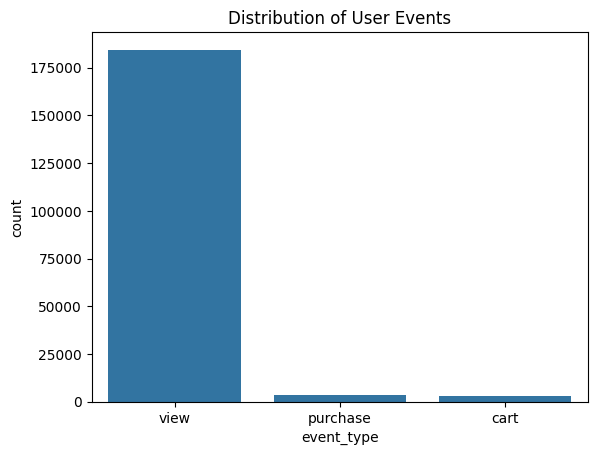

In [29]:
df['event_type'].value_counts()
sns.countplot(x='event_type', data=df)
plt.title("Distribution of User Events")
plt.show()

# **Analysis user activity**

In [24]:
df['user_id'].nunique()

36874

In [25]:
df['product_id'].nunique()

29488

# **Conversion Rate**

In [35]:
view_to_cart = cart_users / view_users
cart_to_purchase = purchase_users / cart_users
view_to_cart, cart_to_purchase

(0.0421809304218093, 1.7485530546623793)

# **Funnel analysis**

In [36]:
# purchase
view_users = df[df['event_type']=='view']['user_id'].nunique()
cart_users = df[df['event_type']=='cart']['user_id'].nunique()
purchase_users = df[df['event_type']=='purchase']['user_id'].nunique()
view_users, cart_users, purchase_users

(36865, 1555, 2719)

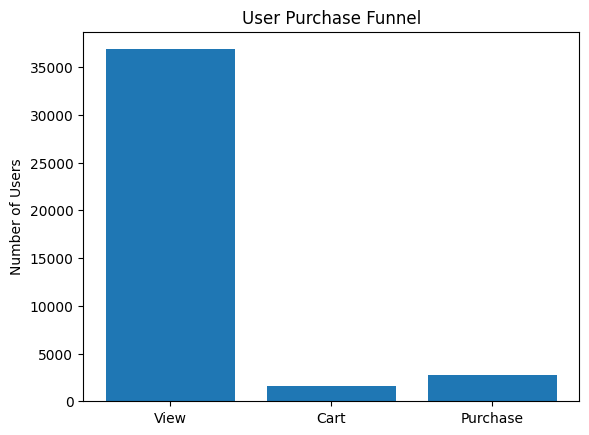

In [37]:
steps = ['View','Cart','Purchase']
values = [view_users, cart_users, purchase_users]

plt.bar(steps, values)
plt.title("User Purchase Funnel")
plt.ylabel("Number of Users")
plt.show()

# Product Category Analysis

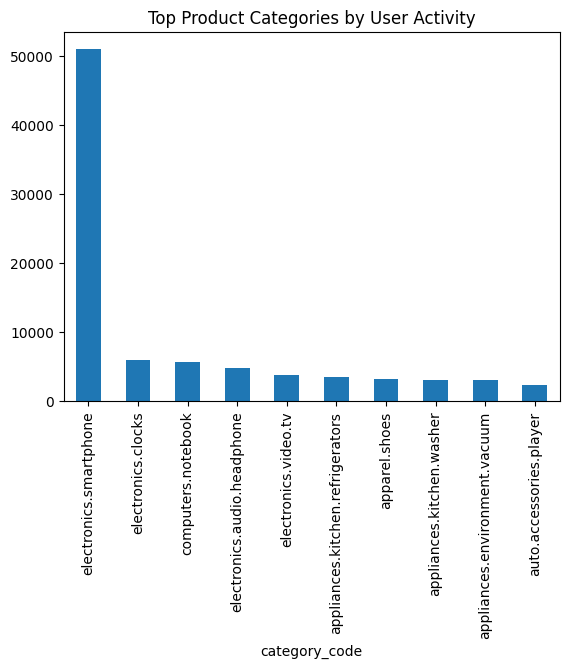

In [38]:
top_categories = df['category_code'].value_counts().head(10)
top_categories
#กราฟ
top_categories.plot(kind='bar')
plt.title("Top Product Categories by User Activity")
plt.show()

# **User Activity (Time)**

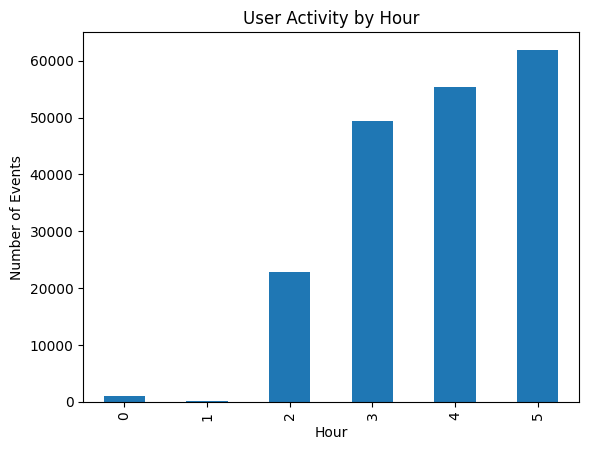

,count
hour,
0,1083
1,121
2,22886
3,49409
4,55290
5,61898


In [51]:
import matplotlib.pyplot as plt
activity_by_hour = df['hour'].value_counts().sort_index()
activity_by_hour.plot(kind='bar')
plt.title("User Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.show()

# ผลลัพธ์ของbar chart
df['hour'].value_counts().sort_index()

**insight** :
กิจกรรมuserเพิ่มขึ้นชัดเจนหลังชั่วโมงที่2
และสูงสุดชั่วโมงที่5 userมีแนวโน้มใช้งานมากขึ้นในช่วงเวลาหลัง

# **Purchase Behavior Analysis**

In [50]:
purchase_df = df[df['event_type']=='purchase']

purchase_df['category_code'].value_counts().head(10)

,count
category_code,
electronics.smartphone,1567
electronics.audio.headphone,136
computers.notebook,97
appliances.kitchen.washer,85
electronics.clocks,75
electronics.video.tv,69
appliances.environment.vacuum,55
appliances.kitchen.refrigerators,49
appliances.environment.air_heater,21
